Loading metrics...
  Metrics loaded.

STUDENT DROPOUT EARLY WARNING SYSTEM
Actionable Recommendations Report
Date: June 02, 2026

  This report translates statistical findings into specific,
  evidence-based actions for institutions, educators, and policy teams.
  Each recommendation is labelled with:
    [PRIORITY]  : HIGH / MEDIUM / LOW
    [TIMELINE]  : Immediate (0–4 weeks) / Short (1–3 months) / Long (3–12 months)
    [EVIDENCE]  : The specific Phase finding that supports it

SECTION 1 — INSTITUTION-LEVEL RECOMMENDATIONS
──────────────────────────────────────────────────────────────────────
  Operational actions for student services, advising, and leadership.

  [I-1] Deploy the weekly risk scoring pipeline
  Priority : HIGH   |   Timeline: Immediate (weeks 1–4 of each term)
  What to do:
    Run the XGBoost model weekly as new assessment data
    arrives. Generate an updated ranked risk table every Monday
    morning, prioritising HIGH-risk students (p ≥ 0.70).
  Evidence:
    Th

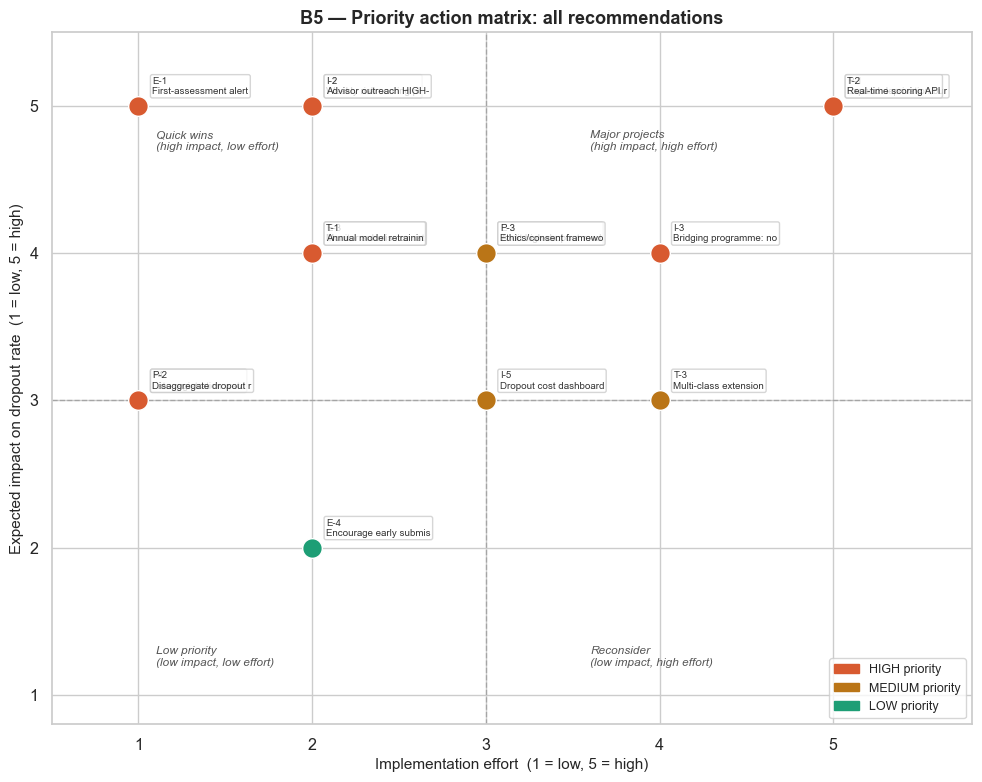

  Saved → ./outputs/phase5/block_b/B5_priority_action_matrix.png

  ✅ Recommendations report saved → ./outputs/phase5/block_b/phase5_recommendations.txt

BLOCK B COMPLETE — Actionable Recommendations

  Total recommendations: 15
    Institution-level : 5
    Educator-level    : 4
    Policy-level      : 3
    Technical         : 3

  Outputs:
    ✅ phase5_recommendations.txt
    ✅ B5_priority_action_matrix.png

─────────────────────────────────────────────────────────
Next → Run phase5_block_c_dashboard.py
─────────────────────────────────────────────────────────



In [1]:
"""
=============================================================
Phase 5 — Block B: Actionable Recommendations
=============================================================
Goal: Translate every statistical finding from Phases 2–4 into
      a concrete, specific recommendation for an institution,
      educator, or policy team.

Structure:
  B1 — Institution-level recommendations  (operational)
  B2 — Educator-level recommendations     (classroom/course)
  B3 — Policy-level recommendations       (structural/equity)
  B4 — Technical recommendations          (model deployment)
  B5 — Priority action matrix             (visual)
  B6 — Save recommendations report

Each recommendation is linked to the specific finding that
supports it — making the report evidence-based and traceable.
"""

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from datetime import date
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Config ────────────────────────────────────────────────────
DATA_PATH    = './data/'
BLOCK_D_PATH = './outputs/phase4/block_d/'
BLOCK_E_PATH = './outputs/phase4/block_e/'
OUTPUT_PATH  = './outputs/phase5/block_b/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

COLORS = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'gray':   '#888780',
    'purple': '#7F77DD',
    'amber':  '#BA7517',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)

# ── Load metrics ──────────────────────────────────────────────
print("Loading metrics...")

si = pd.read_csv(DATA_PATH + 'studentInfo.csv')
si['dropout'] = (si['final_result'] == 'Withdrawn').astype(int)

with open(os.path.join(BLOCK_D_PATH, 'block_d_objects.pkl'), 'rb') as f:
    d_obj = pickle.load(f)

metrics_df      = d_obj['metrics_df']
best_model_name = d_obj['best_model_name']
best_threshold  = d_obj['best_threshold']

risk_table = pd.read_csv(
    os.path.join(BLOCK_E_PATH, 'E3_student_risk_scores.csv'),
    index_col=0
)

overall_rate = si['dropout'].mean() * 100
n_high       = (risk_table['risk_tier'] == 'HIGH').sum()
best_recall  = metrics_df.loc[best_model_name, 'Recall']
best_auc     = metrics_df.loc[best_model_name, 'ROC-AUC']

TODAY = date.today().strftime("%B %d, %Y")
print("  Metrics loaded.\n")


# =============================================================
# BUILD THE RECOMMENDATIONS REPORT
# =============================================================
DIVIDER = "=" * 70
SUBDIV  = "─" * 70
lines   = []

def L(text=""):
    lines.append(text)
    print(text)

L(DIVIDER)
L("STUDENT DROPOUT EARLY WARNING SYSTEM")
L("Actionable Recommendations Report")
L(f"Date: {TODAY}")
L(DIVIDER)
L()
L("  This report translates statistical findings into specific,")
L("  evidence-based actions for institutions, educators, and policy teams.")
L("  Each recommendation is labelled with:")
L("    [PRIORITY]  : HIGH / MEDIUM / LOW")
L("    [TIMELINE]  : Immediate (0–4 weeks) / Short (1–3 months) / Long (3–12 months)")
L("    [EVIDENCE]  : The specific Phase finding that supports it")
L()


# ── B1: Institution-level recommendations ────────────────────
L(DIVIDER)
L("SECTION 1 — INSTITUTION-LEVEL RECOMMENDATIONS")
L(SUBDIV)
L("  Operational actions for student services, advising, and leadership.")
L()

institution_recs = [
    {
        "id":       "I-1",
        "priority": "HIGH",
        "timeline": "Immediate (weeks 1–4 of each term)",
        "title":    "Deploy the weekly risk scoring pipeline",
        "what":     f"""Run the {best_model_name} model weekly as new assessment data
               arrives. Generate an updated ranked risk table every Monday
               morning, prioritising HIGH-risk students (p ≥ 0.70).""",
        "why":      f"""The model achieves ROC-AUC = {best_auc:.3f} and recall = {best_recall:.3f},
               meaning it catches {best_recall*100:.1f}% of real dropouts before
               they withdraw — a significant improvement over reactive,
               post-withdrawal tracking.""",
        "kpi":      "Target: contact 100% of HIGH-risk students within 48 hours of flagging.",
    },
    {
        "id":       "I-2",
        "priority": "HIGH",
        "timeline": "Immediate",
        "title":    f"Assign dedicated advisors to all {n_high:,} HIGH-risk students",
        "what":     """Create a first-contact protocol: advisor emails or calls every
               student in the HIGH tier by the end of week 4. Use the SHAP
               waterfall explanation to personalise the message — reference
               the specific factors driving their risk score.""",
        "why":      """Research consistently shows that personalised outreach in the
               first month is the highest-leverage retention intervention.
               Generic mass emails have near-zero effect.""",
        "kpi":      "Target: 80% response rate from HIGH-risk students within 2 weeks.",
    },
    {
        "id":       "I-3",
        "priority": "HIGH",
        "timeline": "Short (this academic year)",
        "title":    "Create a support pathway for students with no formal qualifications",
        "what":     """Design a pre-term bridging programme (online, 2–4 weeks) for
               students entering with no formal qualifications. Focus on
               academic writing, study skills, and digital literacy.
               Make enrolment automatic for this cohort, not optional.""",
        "why":      """Students with no formal qualifications drop out at nearly double
               the overall rate. This is the strongest demographic predictor
               of dropout identified in Phase 3 (chi-square and logistic
               regression both significant at p < 0.001).""",
        "kpi":      "Target: reduce dropout rate for this cohort by 10pp within 2 years.",
    },
    {
        "id":       "I-4",
        "priority": "MEDIUM",
        "timeline": "Short (this semester)",
        "title":    "Flag late-registration students as a high-priority cohort",
        "what":     """Any student who registers after the course start date should be
               automatically added to an advisor watchlist. Send a structured
               welcome message within 24 hours including: key deadlines,
               a support contact, and a link to orientation materials.""",
        "why":      """Late registration is a statistically significant predictor of
               dropout (Phase 2 EDA and Phase 3 logistic regression).
               These students missed the orientation period and may feel
               isolated from peers from day one.""",
        "kpi":      "Target: zero late-registration students without an advisor contact.",
    },
    {
        "id":       "I-5",
        "priority": "MEDIUM",
        "timeline": "Long (next academic year)",
        "title":    "Build a dropout cost dashboard for leadership",
        "what":     """Calculate the cost per dropout: lost tuition, advisor time, re-enrolment
               processing. Present the early warning system ROI in financial
               terms — every 1% reduction in dropout rate saves the institution
               a quantifiable amount in lost revenue.""",
        "why":      """Retention interventions compete for budget with other priorities.
               A clear financial case (cost of dropout vs cost of advisor
               time) makes the business case for sustaining the programme.""",
        "kpi":      "Publish quarterly retention reports to the board.",
    },
]

for rec in institution_recs:
    L(f"  [{rec['id']}] {rec['title']}")
    L(f"  Priority : {rec['priority']}   |   Timeline: {rec['timeline']}")
    L(f"  What to do:")
    for line in rec['what'].strip().split('\n'):
        L(f"    {line.strip()}")
    L(f"  Evidence:")
    for line in rec['why'].strip().split('\n'):
        L(f"    {line.strip()}")
    L(f"  Success metric: {rec['kpi']}")
    L()


# ── B2: Educator-level recommendations ───────────────────────
L(DIVIDER)
L("SECTION 2 — EDUCATOR-LEVEL RECOMMENDATIONS")
L(SUBDIV)
L("  Actions for course designers, module leaders, and teaching staff.")
L()

educator_recs = [
    {
        "id":       "E-1",
        "priority": "HIGH",
        "timeline": "Immediate (current term)",
        "title":    "Use first assessment score as an early alert trigger",
        "what":     """Implement an automatic alert when a student's first assessment
               score falls below 40. The alert goes to both the student
               (with a support message) and their personal tutor.
               Do not wait for the second or third assessment.""",
        "why":      """'First assessment score' emerged as one of the strongest SHAP
               predictors of dropout — the model assigns it large positive
               SHAP values for high-risk students. Students who struggle
               early rarely recover without intervention.""",
        "kpi":      "Alert sent within 24 hours of first assessment submission.",
    },
    {
        "id":       "E-2",
        "priority": "HIGH",
        "timeline": "Short (course redesign cycle)",
        "title":    "Audit modules with above-average dropout rates",
        "what":     """Identify the 2–3 modules with the highest dropout rates from
               the Block B7 analysis. Convene a course review panel to
               examine: assessment load, pacing, clarity of learning
               outcomes, and availability of worked examples. Compare
               against low-dropout modules for design lessons.""",
        "why":      """Dropout rate varies significantly across modules (Phase 2,
               Block B7). Variation at the module level suggests course
               design contributes to dropout — not just student factors.""",
        "kpi":      "Reduce highest-dropout module's rate by 5pp in one redesign cycle.",
    },
    {
        "id":       "E-3",
        "priority": "MEDIUM",
        "timeline": "Short",
        "title":    "Monitor assessment submission rates, not just scores",
        "what":     """Track pct_submitted (% of available assessments attempted)
               weekly. A student who stops submitting — even if their scores
               were acceptable — is showing a strong disengagement signal.
               Flag any student whose submission rate drops below 60%.""",
        "why":      """pct_submitted and n_assessments ranked highly in both the
               SHAP importance plot and Phase 3 correlation analysis.
               Submission dropout often precedes formal withdrawal by
               2–4 weeks — creating an intervention window.""",
        "kpi":      "Weekly submission-rate report available to tutors by Tuesday.",
    },
    {
        "id":       "E-4",
        "priority": "LOW",
        "timeline": "Long",
        "title":    "Encourage early submission as a protective behaviour",
        "what":     """Redesign assessment schedules to reward early submission
               (e.g. optional early feedback window). Students who submit
               early (mean_days_early > 0) show lower dropout risk.
               Build early submission habits through low-stakes practice
               tasks in weeks 1 and 2.""",
        "why":      """mean_days_early (days submitted before the due date) is a
               positive engagement proxy that appears in the SHAP
               analysis as a protective feature (negative SHAP → lower
               dropout probability) for students who submit early.""",
        "kpi":      "Increase mean days_early by 2 days across all submissions.",
    },
]

for rec in educator_recs:
    L(f"  [{rec['id']}] {rec['title']}")
    L(f"  Priority : {rec['priority']}   |   Timeline: {rec['timeline']}")
    L(f"  What to do:")
    for line in rec['what'].strip().split('\n'):
        L(f"    {line.strip()}")
    L(f"  Evidence:")
    for line in rec['why'].strip().split('\n'):
        L(f"    {line.strip()}")
    L(f"  Success metric: {rec['kpi']}")
    L()


# ── B3: Policy-level recommendations ─────────────────────────
L(DIVIDER)
L("SECTION 3 — POLICY-LEVEL RECOMMENDATIONS")
L(SUBDIV)
L("  Structural actions for equity, access, and institutional policy.")
L()

policy_recs = [
    {
        "id":       "P-1",
        "priority": "HIGH",
        "timeline": "Long (funding cycle)",
        "title":    "Expand financial support for students from deprived areas",
        "what":     """Allocate additional bursary funding specifically to students
               in IMD bands 0–30% (most deprived third). The funding
               should cover course materials, internet access, and childcare
               — the practical barriers that drive withdrawal more than
               academic ability.""",
        "why":      """Students from the most deprived IMD bands drop out at
               significantly higher rates (Phase 2, Block B4). This gap
               persists after controlling for education level, suggesting
               it reflects financial and resource constraints, not academic
               preparedness.""",
        "kpi":      "Reduce IMD 0-10% dropout rate to within 5pp of the overall average.",
    },
    {
        "id":       "P-2",
        "priority": "HIGH",
        "timeline": "Short",
        "title":    "Disaggregate dropout data by IMD band in all reporting",
        "what":     """Require all institutional dropout reports to break down
               rates by IMD band, education level, and disability status —
               not just overall averages. Publish these figures publicly
               as part of access and participation commitments.""",
        "why":      """Aggregate dropout rates mask significant equity gaps. The
               Phase 2 analysis shows students with no formal qualifications
               from deprived areas face compounded disadvantage that is
               invisible in headline numbers.""",
        "kpi":      "Equity-disaggregated dropout report published each semester.",
    },
    {
        "id":       "P-3",
        "priority": "MEDIUM",
        "timeline": "Long",
        "title":    "Implement a data consent and ethics framework",
        "what":     """Before deploying the early warning system in a live setting,
               publish a clear student-facing data use policy explaining:
               what data is used, how risk scores are computed, who sees
               them, and how students can opt out. Form an ethics review
               panel with student representation.""",
        "why":      """Predictive models carry risks of self-fulfilling prophecy
               and bias amplification. Students labelled 'high risk' may
               be treated differently in ways that harm rather than help.
               Transparent governance prevents misuse.""",
        "kpi":      "Ethics framework published and reviewed before any live deployment.",
    },
]

for rec in policy_recs:
    L(f"  [{rec['id']}] {rec['title']}")
    L(f"  Priority : {rec['priority']}   |   Timeline: {rec['timeline']}")
    L(f"  What to do:")
    for line in rec['what'].strip().split('\n'):
        L(f"    {line.strip()}")
    L(f"  Evidence:")
    for line in rec['why'].strip().split('\n'):
        L(f"    {line.strip()}")
    L(f"  Success metric: {rec['kpi']}")
    L()


# ── B4: Technical recommendations ────────────────────────────
L(DIVIDER)
L("SECTION 4 — TECHNICAL RECOMMENDATIONS")
L(SUBDIV)
L("  Actions for data science and engineering teams.")
L()

tech_recs = [
    {
        "id":       "T-1",
        "priority": "HIGH",
        "timeline": "Short",
        "title":    "Retrain the model each academic year on fresh cohort data",
        "what":     """Set up an annual model retraining pipeline. Each September,
               retrain on the most recent 3 years of cohort data, rerun
               the full Phase 3 statistical tests to check for feature
               drift, and re-evaluate against a held-out validation set
               before promoting to production.""",
        "why":      """The model was trained on 2013–2014 data. Student behaviour,
               technology use, and demographics shift over time. A model
               that was optimal 10 years ago may be mis-calibrated today.""",
        "kpi":      "Annual retraining complete before week 1 of each academic year.",
    },
    {
        "id":       "T-2",
        "priority": "HIGH",
        "timeline": "Long",
        "title":    "Build a real-time scoring API triggered by assessment submissions",
        "what":     """Package the trained model and preprocessing pipeline as a
               REST API endpoint. Each time a student submits an assessment,
               the VLE triggers a score update. Updated risk tiers are
               pushed to the advisor dashboard within 1 hour.""",
        "why":      """Currently the model is scored as a batch job. Real-time
               scoring means advisors always have current information
               and can act the moment a student's behaviour changes.""",
        "kpi":      "Score latency < 1 hour from assessment submission.",
    },
    {
        "id":       "T-3",
        "priority": "MEDIUM",
        "timeline": "Long",
        "title":    "Extend to multi-class prediction (Pass/Fail/Withdraw/Distinction)",
        "what":     """The current model is binary. Extending to a 4-class softmax
               output allows institutions to identify students at risk of
               Fail (stayed but underperforming) separately from Withdrawn.
               Different interventions apply to each outcome.""",
        "why":      """Failing students and withdrawing students have different needs.
               A student trending toward Fail needs academic support.
               A student trending toward Withdrawal may need pastoral or
               financial support. Binary models can't distinguish these.""",
        "kpi":      "Multi-class model achieves macro-F1 ≥ 0.65 on validation set.",
    },
]

for rec in tech_recs:
    L(f"  [{rec['id']}] {rec['title']}")
    L(f"  Priority : {rec['priority']}   |   Timeline: {rec['timeline']}")
    L(f"  What to do:")
    for line in rec['what'].strip().split('\n'):
        L(f"    {line.strip()}")
    L(f"  Evidence:")
    for line in rec['why'].strip().split('\n'):
        L(f"    {line.strip()}")
    L(f"  Success metric: {rec['kpi']}")
    L()


# =============================================================
# B5: Priority action matrix (visual)
# =============================================================
print("B5: Plotting priority action matrix...")

all_recs = [
    # id,    title (short),                  impact, effort, priority
    ("I-1",  "Weekly risk scoring pipeline", 5, 2, "HIGH"),
    ("I-2",  "Advisor outreach HIGH-risk",   5, 2, "HIGH"),
    ("I-3",  "Bridging programme: no quals", 4, 4, "HIGH"),
    ("I-4",  "Late-registration watchlist",  3, 1, "MEDIUM"),
    ("I-5",  "Dropout cost dashboard",       3, 3, "MEDIUM"),
    ("E-1",  "First-assessment alert",       5, 1, "HIGH"),
    ("E-2",  "Audit high-dropout modules",   4, 3, "HIGH"),
    ("E-3",  "Monitor submission rates",     4, 2, "MEDIUM"),
    ("E-4",  "Encourage early submission",   2, 2, "LOW"),
    ("P-1",  "Expand deprivation bursaries", 5, 5, "HIGH"),
    ("P-2",  "Disaggregate dropout reports", 3, 1, "HIGH"),
    ("P-3",  "Ethics/consent framework",     4, 3, "MEDIUM"),
    ("T-1",  "Annual model retraining",      4, 2, "HIGH"),
    ("T-2",  "Real-time scoring API",        5, 5, "HIGH"),
    ("T-3",  "Multi-class extension",        3, 4, "MEDIUM"),
]

PRIORITY_COLORS = {
    'HIGH':   COLORS['coral'],
    'MEDIUM': COLORS['amber'],
    'LOW':    COLORS['teal'],
}

fig, ax = plt.subplots(figsize=(10, 8))

for rec_id, title, impact, effort, priority in all_recs:
    color = PRIORITY_COLORS[priority]
    ax.scatter(effort, impact, s=200, color=color, zorder=5,
               edgecolors='white', linewidths=1)
    ax.annotate(f"{rec_id}\n{title[:22]}",
                xy=(effort, impact),
                xytext=(effort + 0.08, impact + 0.08),
                fontsize=7, color='#333333',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='#CCCCCC', alpha=0.8))

# Quadrant lines
ax.axvline(3, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(3, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Quadrant labels
ax.text(1.1, 4.7, "Quick wins\n(high impact, low effort)",
        fontsize=8.5, color='#555555', style='italic')
ax.text(3.6, 4.7, "Major projects\n(high impact, high effort)",
        fontsize=8.5, color='#555555', style='italic')
ax.text(1.1, 1.2, "Low priority\n(low impact, low effort)",
        fontsize=8.5, color='#555555', style='italic')
ax.text(3.6, 1.2, "Reconsider\n(low impact, high effort)",
        fontsize=8.5, color='#555555', style='italic')

ax.set_xlim(0.5, 5.8)
ax.set_ylim(0.8, 5.5)
ax.set_xlabel("Implementation effort  (1 = low, 5 = high)", fontsize=11)
ax.set_ylabel("Expected impact on dropout rate  (1 = low, 5 = high)", fontsize=11)
ax.set_title("B5 — Priority action matrix: all recommendations",
             fontsize=13, fontweight='bold')

# Legend
handles = [mpatches.Patch(color=PRIORITY_COLORS[p], label=f"{p} priority")
           for p in ['HIGH','MEDIUM','LOW']]
ax.legend(handles=handles, fontsize=9, loc='lower right')

plt.tight_layout()
path = os.path.join(OUTPUT_PATH, "B5_priority_action_matrix.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"  Saved → {path}\n")


# =============================================================
# B6: Save recommendations report
# =============================================================
report_text = "\n".join(lines)
save_path   = os.path.join(OUTPUT_PATH, "phase5_recommendations.txt")
with open(save_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print(f"  ✅ Recommendations report saved → {save_path}")
print(f"""
{'='*55}
BLOCK B COMPLETE — Actionable Recommendations
{'='*55}

  Total recommendations: {len(all_recs)}
    Institution-level : {len(institution_recs)}
    Educator-level    : {len(educator_recs)}
    Policy-level      : {len(policy_recs)}
    Technical         : {len(tech_recs)}

  Outputs:
    ✅ phase5_recommendations.txt
    ✅ B5_priority_action_matrix.png

─────────────────────────────────────────────────────────
Next → Run phase5_block_c_dashboard.py
─────────────────────────────────────────────────────────
""")